# Olist Database - Error Structure and Promise Windows

**Author:** Alejandro Mezio

Does MAE tell the whole story? Error metrics revisited, and the model reframed as a promise-date system.

## 15.&nbsp;Motivation

Part 2 selected models by **MAE**, declared before the comparison. MAE prices a 2-day miss identically whether the delivery took 1 day or 50, yet those two misses are very different experiences for a customer. This notebook asks three questions:

1. **Diagnostic:** how does the frozen model's error actually scale with the target? (Section 16, no retraining.)
2. **Relative-error experiment:** does training the same configuration on a log-transformed target buy relative accuracy on short deliveries? (Section 17.)
3. **The business question:** the product is a *promise date*, where the real asymmetry is late-vs-early, not relative-vs-absolute. Can a quantile model match the platform's promise reliability with less padding? (Section 18.)

**Metric discipline:** MAE remains the declared selection metric of Part 2; nothing here re-ranks those results. Sections 17 and 18 are new experiments, declared before running them.

### 15.1 Metric catalogue

| Metric | Definition | Optimal point predictor | Key properties |
|---|---|---|---|
| **MAE** | mean of \|error\| | conditional **median** | Same units as the target (days); robust to outliers; linear penalty. [User guide](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-error) · [`mean_absolute_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html) |
| **RMSE** | sqrt of mean squared error | conditional **mean** | Quadratic penalty amplifies large misses; sensitive to outliers. [User guide](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error) · [`root_mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html) |
| **Median AE** | median of \|error\| | conditional median | The "typical" error; ignores the tail entirely. [`median_absolute_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.median_absolute_error.html) |
| **MAPE** | mean of \|error\|/\|y\| | ~conditional weighted median | Scale-free; **undefined at y = 0** (scikit-learn substitutes an epsilon, producing astronomically large values instead of an error); dominated by small-y rows; asymmetric: over-prediction is unbounded while under-prediction caps at 100%, so optimizing it favors **under-prediction**. [User guide](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-percentage-error) · [`mean_absolute_percentage_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html) |
| **MSLE / RMSLE** | mean of (log1p(pred) − log1p(y))² | conditional mean in log space | Relative errors, defined at y = 0; for a fixed absolute error an under-prediction yields the larger log-difference, so it penalizes under-prediction more (opposite direction to MAPE). [User guide](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-log-error) · [`mean_squared_log_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_log_error.html) |
| **log-MAE** (computed inline) | mean of \|log1p(pred) − log1p(y)\| | conditional median in log space | Our relative metric of choice: exp of it reads as a "typical multiplicative factor" (e.g. ×1.4); since medians commute with monotone transforms, a log-space median model back-transforms to a median in days. No scikit-learn function; two lines of numpy. |
| **WAPE** (computed inline) | sum \|error\| / sum y = MAE / mean(y) | — | Scale-free *aggregate* (common in logistics forecasting); robust to small denominators but does not weight rows relatively, so it rescales MAE rather than answering the relative-error question. |
| **Pinball (quantile) loss** | asymmetric linear loss with slope α | conditional **α-quantile** | α = 0.5 recovers MAE/2; α = 0.9 is minimized by the 90th percentile: the natural loss for promise dates. Evaluation: [user guide](https://scikit-learn.org/stable/modules/model_evaluation.html#pinball-loss) · [`mean_pinball_loss`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_pinball_loss.html). Training: XGBoost [`reg:quantileerror` with `quantile_alpha`](https://xgboost.readthedocs.io/en/stable/parameter.html) ([worked example](https://xgboost.readthedocs.io/en/stable/python/examples/quantile_regression.html); use `hist`, not `exact`).

### Setup

The pipeline definitions are imported from `src/olist_delivery`: the notebook consumes the same single source of truth as the CLIs and tests.

In [1]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, median_absolute_error,
                             root_mean_squared_error,
                             mean_absolute_percentage_error,
                             mean_squared_log_error, mean_pinball_loss)

from src.olist_delivery.pipeline import (FEATURES, TARGET, XGB_BEST,
                                         RANDOM_STATE, load_dataset,
                                         make_preprocessor, make_model)
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

%matplotlib inline

models_path = './models'
os.makedirs(models_path, exist_ok=True)

In [2]:
df_final = load_dataset()
X = df_final[FEATURES]
y = df_final[[TARGET, 'days_estimated']]   # keep the platform promise for benchmarks
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=RANDOM_STATE)
y_true = y_test[TARGET].to_numpy()

# The frozen Part2 winner, trained by the src CLI (python -m src.olist_delivery.train)
frozen = joblib.load('models/delivery_model.joblib')
pred_frozen = frozen.predict(X_test)
print(f"frozen model | test MAE {mean_absolute_error(y_true, pred_frozen):.4f} "
      f"(Part 2 checkpoint: 4.3822)")

frozen model | test MAE 4.3822 (Part 2 checkpoint: 4.3822)


### 15.2 Why MAPE specifically does not fit this dataset

Three data-grounded reasons, computed below: the target contains zeros (same-day deliveries), short deliveries would dominate the average, and the under-prediction incentive points exactly the wrong way for delivery promises (a late arrival is the expensive error).

In [3]:
yt = y_train[TARGET]
print(f"target range: {yt.min():.0f} to {yt.max():.0f} days | zeros in data: {(yt == 0).sum()}")
for t in (1, 2, 3):
    print(f"share of orders with y <= {t}: {100 * (yt <= t).mean():.2f}%")
w_small = (1 / yt[yt <= 3].clip(lower=1)).mean()
w_large = (1 / yt[yt >= 20]).mean()
print(f"mean MAPE weight (1/y): y<=3 days: {w_small:.2f} vs y>=20 days: {w_large:.3f} "
      f"({w_small / w_large:.0f}x)")

# sklearn's epsilon substitution at y=0 in action:
print(f"\nMAPE of the frozen model on the test set: "
      f"{mean_absolute_percentage_error(y_true, pred_frozen):.3e}  <- inflated by y=0 rows")
mask = y_true > 0
print(f"MAPE excluding y=0 rows: "
      f"{mean_absolute_percentage_error(y_true[mask], pred_frozen[mask]):.3f}")

target range: 0 to 87 days | zeros in data: 11
share of orders with y <= 1: 1.70%
share of orders with y <= 2: 5.15%
share of orders with y <= 3: 9.27%
mean MAPE weight (1/y): y<=3 days: 0.52 vs y>=20 days: 0.038 (13x)

MAPE of the frozen model on the test set: 2.545e+12  <- inflated by y=0 rows
MAPE excluding y=0 rows: 0.465


## 16.&nbsp;Error structure of the frozen model

No retraining here: we measure how the Part 2 winner's error scales with the target, using the catalogue above.

In [4]:
def log_mae(y, p):
    return float(np.mean(np.abs(np.log1p(p) - np.log1p(y))))

def wape(y, p):
    return float(np.abs(y - p).sum() / y.sum())

mask = y_true > 0
overall = pd.Series({
    'MAE (days)': mean_absolute_error(y_true, pred_frozen),
    'Median AE (days)': median_absolute_error(y_true, pred_frozen),
    'RMSE (days)': root_mean_squared_error(y_true, pred_frozen),
    'WAPE': wape(y_true, pred_frozen),
    'log-MAE': log_mae(y_true, pred_frozen),
    'typical ratio (exp of log-MAE)': np.exp(log_mae(y_true, pred_frozen)),
    'RMSLE': np.sqrt(mean_squared_log_error(y_true, pred_frozen)),
    'MAPE (y>0 only)': mean_absolute_percentage_error(y_true[mask], pred_frozen[mask]),
})
overall.round(4)

MAE (days)                        4.3822
Median AE (days)                  2.8145
RMSE (days)                       7.1386
WAPE                              0.3846
log-MAE                           0.3612
typical ratio (exp of log-MAE)    1.4350
RMSLE                             0.4656
MAPE (y>0 only)                   0.4650
dtype: float64

          n     mae  median_ae  typical_ratio
band                                         
0-2     892   3.013      2.742          2.106
3-5    2848   2.648      1.906          1.471
6-10   6538   2.603      2.183          1.311
11-20  5776   3.629      3.086          1.311
21-40  1747  12.862     12.122          1.908
40+     227  36.650     33.673          3.502


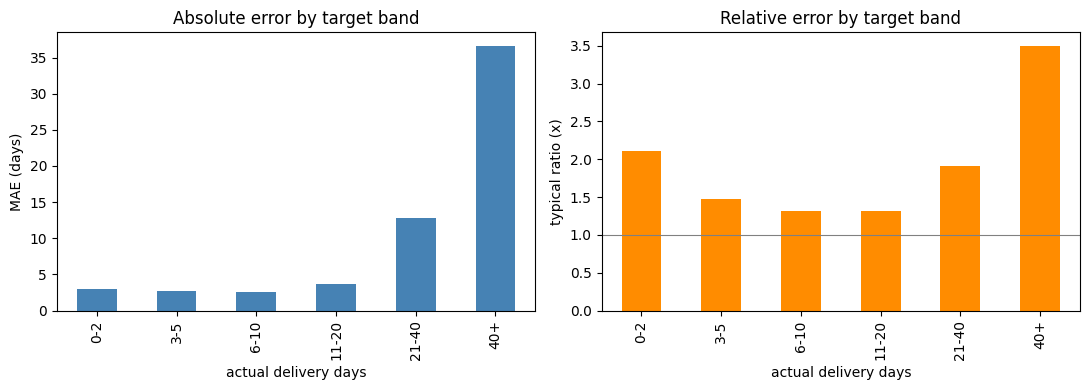

In [5]:
bands = pd.cut(y_true, bins=[-0.1, 2, 5, 10, 20, 40, np.inf],
               labels=['0-2', '3-5', '6-10', '11-20', '21-40', '40+'])
res = pd.DataFrame({'y': y_true, 'pred': pred_frozen, 'band': bands})
res['abs_err'] = (res.y - res.pred).abs()
res['log_err'] = (np.log1p(res.pred) - np.log1p(res.y)).abs()

by_band = res.groupby('band', observed=True).agg(
    n=('y', 'size'),
    mae=('abs_err', 'mean'),
    median_ae=('abs_err', 'median'),
    typical_ratio=('log_err', lambda s: np.exp(s.mean())),
).round(3)
print(by_band)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_band['mae'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Absolute error by target band')
axes[0].set_ylabel('MAE (days)'); axes[0].set_xlabel('actual delivery days')
by_band['typical_ratio'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].axhline(1, color='grey', lw=0.8)
axes[1].set_title('Relative error by target band')
axes[1].set_ylabel('typical ratio (x)'); axes[1].set_xlabel('actual delivery days')
plt.tight_layout(); plt.show()

### Takeaway (section 16)

**The error is U-shaped in the target, in both absolute and relative terms.** Absolute error is lowest mid-range (MAE 2.6 days for 6-10-day deliveries) and explodes in the long tail (12.9 for 21-40, 36.7 for 40+). The relative view adds the other half of the story: the typical ratio is worst at **both** extremes: ×2.11 for 0-2-day deliveries (the model's ~1.6-day prediction floor means it simply cannot say "tomorrow") and ×3.50 for 40+ days, with a comfortable ×1.31 across the 6-20-day mid-range where 68% of orders live.

So the intuition behind this notebook is half-confirmed: MAE indeed hides poor relative performance on short deliveries, but a relative metric would not have "fixed" the picture; it would have traded one bad tail for the other. The blind spot is the tails, not the units.

## 17.&nbsp;Declared experiment: the same model on a log target

Same frozen hyperparameters, target `log1p(days)`, predictions back-transformed with `expm1`. The back-transform is clean because MAE-optimal predictions are conditional medians and medians commute with monotone transforms: the result is still a median in days. Declared question: **how many days of overall MAE does relative accuracy on short deliveries cost?**

In [6]:
log_path = os.path.join(models_path, 'part4_xgb_log_random.pkl')
if os.path.exists(log_path):
    with open(log_path, 'rb') as f:
        model_log = pickle.load(f)
else:
    model_log = make_model()
    model_log.fit(X_train, np.log1p(y_train[TARGET]))
    with open(log_path, 'wb') as f:
        pickle.dump(model_log, f)

pred_log = np.expm1(model_log.predict(X_test))

res['pred_log'] = pred_log
res['abs_err_log_model'] = (res.y - res.pred_log).abs()
res['log_err_log_model'] = (np.log1p(res.pred_log) - np.log1p(res.y)).abs()

compare = pd.DataFrame({
    'MAE frozen': res.groupby('band', observed=True)['abs_err'].mean(),
    'MAE log-model': res.groupby('band', observed=True)['abs_err_log_model'].mean(),
    'ratio frozen': res.groupby('band', observed=True)['log_err'].mean().pipe(np.exp),
    'ratio log-model': res.groupby('band', observed=True)['log_err_log_model'].mean().pipe(np.exp),
}).round(3)
print(compare)
print(f"\noverall MAE:  frozen {res.abs_err.mean():.4f} | log-model {res.abs_err_log_model.mean():.4f}")
print(f"overall log-MAE: frozen {res.log_err.mean():.4f} | log-model {res.log_err_log_model.mean():.4f}")

       MAE frozen  MAE log-model  ratio frozen  ratio log-model
band                                                           
0-2         3.013          2.961         2.106            2.088
3-5         2.648          2.616         1.471            1.465
6-10        2.603          2.583         1.311            1.310
11-20       3.629          3.665         1.311            1.316
21-40      12.862         12.909         1.908            1.915
40+        36.650         36.702         3.502            3.515

overall MAE:  frozen 4.3822 | log-model 4.3838
overall log-MAE: frozen 0.3612 | log-model 0.3613


### Takeaway (section 17)

**Negative result, by the declared rule.** The log-target model improves the short bands marginally (0-2-day MAE 3.01 → 2.96, typical ratio 2.106 → 2.088, about 1%), degrades the mid and long bands by similar margins, and costs +0.002 days of overall MAE (4.3822 → 4.3838). Nothing earns a README place.

The informative reading: the short-delivery relative error is an **information limit, not an objective-function artifact**. With the current features the model cannot distinguish the orders that will arrive in 1-2 days; changing the loss re-labels the ignorance, it does not remove it. MAE and the frozen model keep their jobs.

## 18.&nbsp;Declared experiment: promise windows (P90 quantile)

The deployed product is a **promise date**. Its two quality measures:

- **Coverage**: share of orders arriving on or before the promise.
- **Padding**: mean of (promise − actual arrival), the days of slack a customer sees.

The platform's own estimator achieves 93% coverage at the cost of +11.5 days of mean padding (Part 1). We train the same XGBoost configuration with `reg:quantileerror` at `quantile_alpha=0.9` and ask, apples to apples: **what padding does a P90 model need for comparable coverage?** Evaluated on the random test set and, deployment-faithfully, on Part 3's temporal split (does 90% coverage survive on future data?).

In [7]:
def make_quantile_model(alpha=0.9, **overrides):
    params = {**XGB_BEST, **overrides}
    return Pipeline(steps=[
        ('preprocessor', make_preprocessor()),
        ('model', XGBRegressor(objective='reg:quantileerror',
                               quantile_alpha=alpha, tree_method='hist',
                               random_state=RANDOM_STATE, n_jobs=-1, **params)),
    ])

q_path = os.path.join(models_path, 'part4_xgb_q90_random.pkl')
if os.path.exists(q_path):
    with open(q_path, 'rb') as f:
        model_q90 = pickle.load(f)
else:
    model_q90 = make_quantile_model(0.9)
    model_q90.fit(X_train, y_train[TARGET])
    with open(q_path, 'wb') as f:
        pickle.dump(model_q90, f)

promise = model_q90.predict(X_test)
platform_promise = y_test['days_estimated'].to_numpy()

def promise_report(name, promise, actual):
    coverage = float((actual <= promise).mean())
    padding = float((promise - actual).mean())
    return {'promise': name, 'coverage %': round(100 * coverage, 1),
            'mean padding (days)': round(padding, 2),
            'pinball@0.9': round(mean_pinball_loss(actual, promise, alpha=0.9), 4)}

report_random = pd.DataFrame([
    promise_report('P90 model', promise, y_true),
    promise_report('Platform estimator', platform_promise, y_true),
])
report_random

,promise,coverage %,mean padding (days),pinball@0.9
0,P90 model,90.0,7.63,1.5045
1,Platform estimator,93.5,11.45,1.7337


In [8]:
# Deployment-faithful version: Part 3's temporal split
ts = df_final['order_purchase_timestamp']
cutoff = ts.quantile(0.8)
train_mask = (ts < cutoff) & (df_final['order_delivered_customer_date'] < cutoff)
test_mask = ts >= cutoff
X_tr_t, y_tr_t = X[train_mask], df_final.loc[train_mask, TARGET]
X_te_t = X[test_mask]
y_true_t = df_final.loc[test_mask, TARGET].to_numpy()
platform_t = df_final.loc[test_mask, 'days_estimated'].to_numpy()

qt_path = os.path.join(models_path, 'part4_xgb_q90_temporal.pkl')
if os.path.exists(qt_path):
    with open(qt_path, 'rb') as f:
        model_q90_t = pickle.load(f)
else:
    model_q90_t = make_quantile_model(0.9)
    model_q90_t.fit(X_tr_t, y_tr_t)
    with open(qt_path, 'wb') as f:
        pickle.dump(model_q90_t, f)

promise_t = model_q90_t.predict(X_te_t)
report_temporal = pd.DataFrame([
    promise_report('P90 model (temporal)', promise_t, y_true_t),
    promise_report('Platform estimator (temporal)', platform_t, y_true_t),
])
report_temporal

,promise,coverage %,mean padding (days),pinball@0.9
0,P90 model (temporal),97.8,11.51,1.3008
1,Platform estimator (temporal),96.3,13.08,1.5158


### Takeaway (section 18)

**On the random test the P90 model is exactly calibrated and much tighter than the platform:** 90.0% coverage with 7.6 days of mean padding, versus the platform's 93.5% with 11.5 days; at the 90% target the pinball loss also favors the model (1.50 vs 1.73). Roughly: **4 days tighter promises at the reliability level the model was asked for.**

**On the temporal test the model dominates the platform on both axes at once:** 97.8% coverage with 11.5 days of padding vs 96.3% with 13.1 on genuinely future orders. But note the miscalibration: a quantile trained on the harder past over-covers the easier future (97.8% against a 90% target), the promise-window mirror of Part 3's finding that period difficulty dominates forward behavior. A deployed promise system therefore needs a **recalibration cadence** (rolling or conformal quantiles), not a one-shot fit.

The business line this supports: on forward data, model-based promise dates were both tighter and more reliable than the platform's.

In [9]:
# Persist every number for the write-up
out = {
    'overall_metrics_frozen': overall.round(6).to_dict(),
    'by_band_frozen': by_band.reset_index().to_dict(orient='records'),
    'log_model_compare': compare.reset_index().to_dict(orient='records'),
    'log_model_overall_mae': float(res.abs_err_log_model.mean()),
    'promise_random': report_random.to_dict(orient='records'),
    'promise_temporal': report_temporal.to_dict(orient='records'),
    'cutoff': str(cutoff),
}
with open('scripts/part4_results.json', 'w') as f:
    json.dump(out, f, indent=2, default=str)
print('saved scripts/part4_results.json')

saved scripts/part4_results.json


## 19.&nbsp;Takeaways

1. **MAE's blind spot here is the tails, not the units** (section 16): relative error peaks at both extremes (×2.1 at 0-2 days, ×3.5 at 40+), while the 6-20-day mid-range, 68% of orders, sits at ×1.31. A relative metric would not repair this; it would reweight it.
2. **The log-target experiment is a clean negative result** (section 17): ~1% relative gain on short deliveries for +0.002 days of overall MAE. The short-delivery problem is missing information, not the wrong loss. MAE stays the declared point-prediction metric; MAPE remains unsuitable for this data (zeros, small-y domination, wrong asymmetry: see 15.2).
3. **Reframing the product as a promise date is where the value is** (section 18): a P90 quantile model, same features and hyperparameters, gives calibrated 90% promises 4 days tighter than the platform's on the random test, and dominates the platform on both coverage and padding on the temporal test, while revealing that quantile calibration drifts with period difficulty (97.8% observed vs 90% target).
4. **Closed / opened:** this notebook closes the "which metric" question and opens the deployment-shaped ones: conformal or rolling recalibration of the promise quantile, a coverage-vs-padding sweep over α, and per-band promises for the long tail where all models struggle.